In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.lines import Line2D
import math
import pandas as pd
from datetime import datetime, timedelta

from ebm.params import *

%load_ext autoreload

## ESM model results

In [2]:
%autoreload
from esm.model import get_global_mean

global_mean_r25, global_mean_r1, global_mean_pi = get_global_mean()

/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.

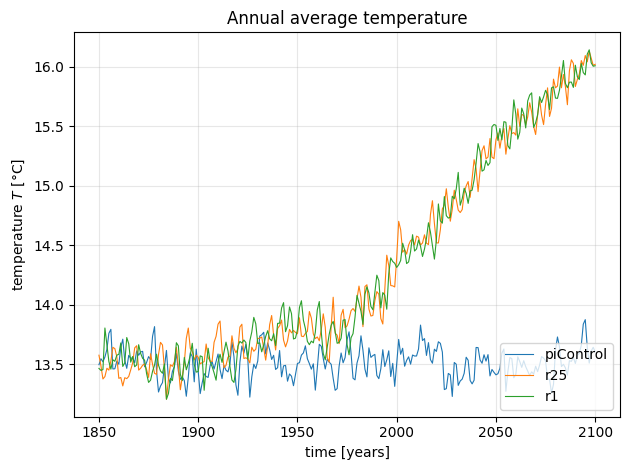

In [55]:
# pre-industrial control
plt.plot(global_mean_pi.time.dt.year, global_mean_pi-273.15, '-', lw=0.8, label='piControl')
# ESM (r25)
plt.plot(global_mean_r25.time.dt.year, global_mean_r25-273.15, '-', lw=0.8, label='r25')
# ESM (r1)
plt.plot(global_mean_r1.time.dt.year, global_mean_r1-273.15, '-', lw=0.8, label='r1')

plt.title('Annual average temperature')
plt.xlabel('time [years]')
plt.ylabel(r'temperature $T$ [°C]')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
# plt.ylim(0, 20)

plt.savefig('plots/hist-sim.png')
plt.savefig('plots/hist-sim.pdf')
plt.show()

## 0D EBM model

$ SW = \frac{S_0}{4} (1-\alpha)$

$ LW = \epsilon \sigma T_{abs}^4 $

$ T_{abs}(t=t_i+1) = T_{abs}(t_i) + \Delta t \frac{SW-LW}{c_e} $ 

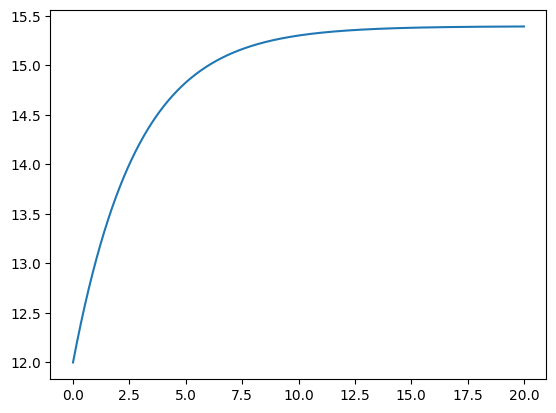

In [4]:
%autoreload
from ebm.model import run_model

# test run
temp, time = run_model()

plt.plot(time, temp)
plt.show()

### Unchanged EBM started in 1981

In [5]:
start_year = 1980
# start_year = 1850
T_init = global_mean_r25.sel(time=str(start_year)).values[0]

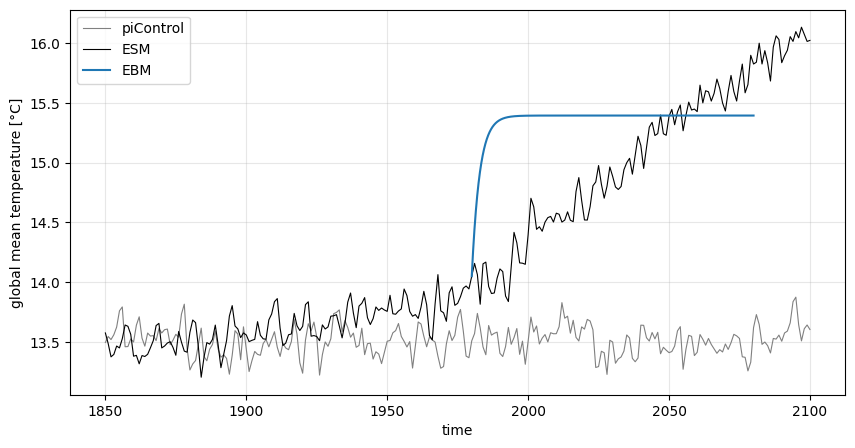

In [6]:
%autoreload
from ebm.model import run_model
from utils import plot_ebm_vs_esm

temp_original, time = run_model(T_ini=T_init, maxtime=100*secyear)

plot_ebm_vs_esm(
    time_ebm=time+start_year,
    temp_ebm=temp_original,
    time_esm=global_mean_r25.time.dt.year,
    temp_esm=global_mean_r25-273.15,
    temp_control=global_mean_pi-273.15
    )

plt.savefig('plots/ebm-vs-esm.png', bbox_inches='tight')
plt.savefig('plots/ebm-vs-esm.pdf', bbox_inches='tight')
# plt.show()

## Sensitivity analysis

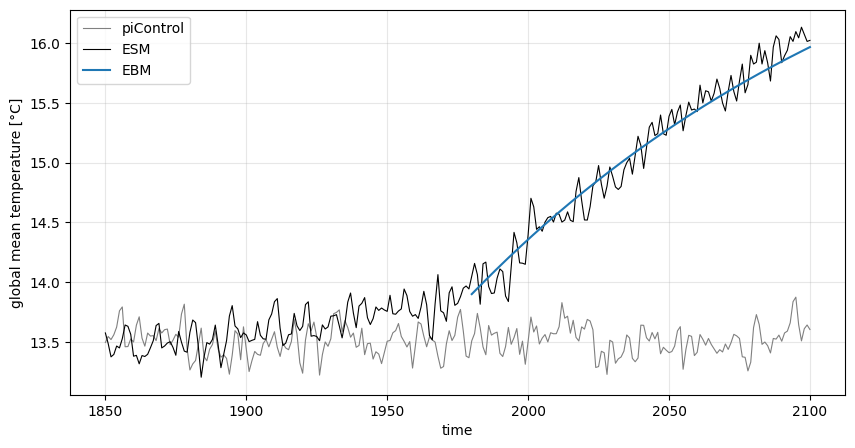

In [54]:
%autoreload
from ebm.model import run_model
from utils import plot_ebm_vs_esm

# temp, time = run_model(T_ini=13.9+273.15, maxtime=120*secyear, alpha=0.295, eps=0.59, sigma=5.70e-8, H=4000)
temp, time = run_model(T_ini=13.9+273.15, maxtime=120*secyear, alpha=0.295, eps=0.594, H=4000)

plot_ebm_vs_esm(
    time_ebm=time+start_year,
    temp_ebm=temp,
    time_esm=global_mean_r25.time.dt.year,
    temp_esm=global_mean_r25-273.15,
    temp_control=global_mean_pi-273.15
    )

- managed to fit pattern for params:
    - $\alpha = 0.295$ -> decreased albedo
    - $\epsilon = 0.594$ -> decreased emissivity
    - $MLD = 4000$ m -> ocean fully mixed -> questionable
- try next:
    - replicate seasonal patterns with temp/time dependent MLD

0.29895


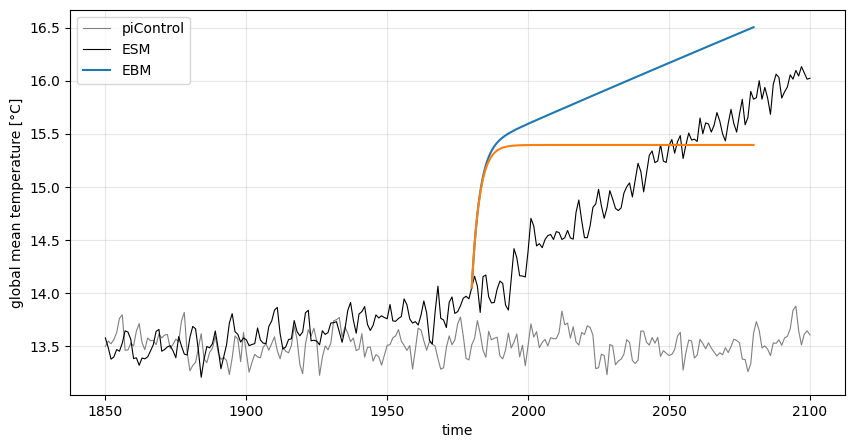

In [8]:
%autoreload
from ebm.model import run_with_changing_H_and_albedo
# from utils import plot_ebm_vs_esm

# Initial albedo
alpha_init=0.3
# albedo after 10 yrs (decrease of 0.34%)
alpha10 = alpha_init * 0.9965
print(alpha10)

d_alpha = (alpha10-alpha_init)/(1000)

# alpha10

temp_albedo_decrease, time, alpha = run_with_changing_H_and_albedo(T_ini=T_init, maxtime=100*secyear, alpha_init=0.3, d_alpha=d_alpha)
# print(time)

plot_ebm_vs_esm(
    time_ebm=time+start_year,
    temp_ebm=temp_albedo_decrease,
    time_esm=global_mean_r25.time.dt.year,
    temp_esm=global_mean_r25-273.15,
    temp_control=global_mean_pi-273.15
    )
plt.plot(time+start_year, temp_original)

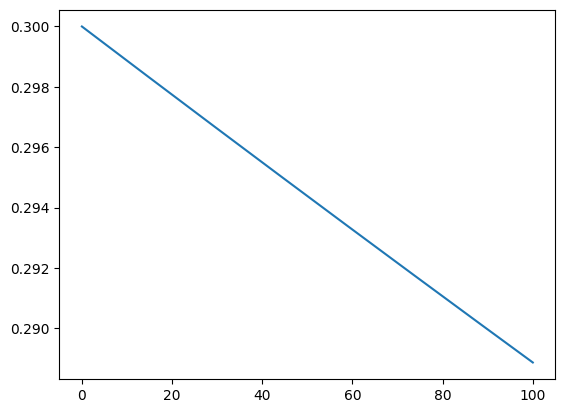

In [9]:
plt.plot(time, alpha)